In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df=pd.read_csv('Employees Data.csv')
df.shape

(1470, 35)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

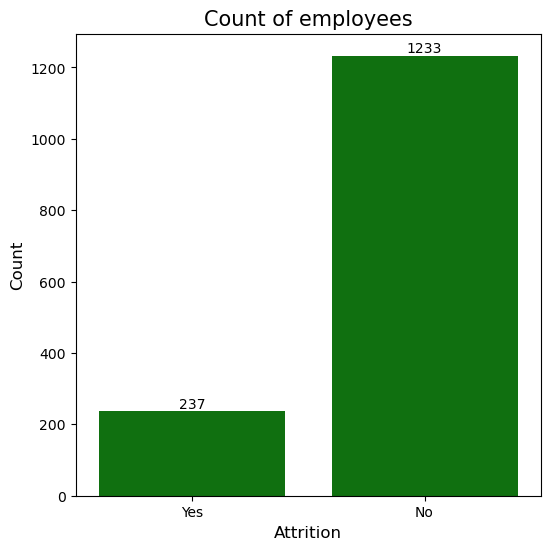

In [13]:
df['AttritionRate'] = df['Attrition'].map({'Yes': 1 , 'No':0})
fig, ax = plt.subplots(figsize = (6,6))
ax = sns.countplot(x='Attrition', data = df,color = 'green')
ax.set_xlabel('Attrition', fontsize = 12)
ax.set_title('Count of employees', fontsize = 15)
ax.set_ylabel('Count', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

In [5]:
# COnverting Ages into Age Categories for better data visualisation

df['AgeGroup'] = pd.cut(df["Age"], bins = [18,25,35,45,60], labels = ['18-24','25-34','35-44','45-60'])

C:\Users\User\AppData\Local\Temp\ipykernel_8896\2489053447.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['AttritionRate'].mean()


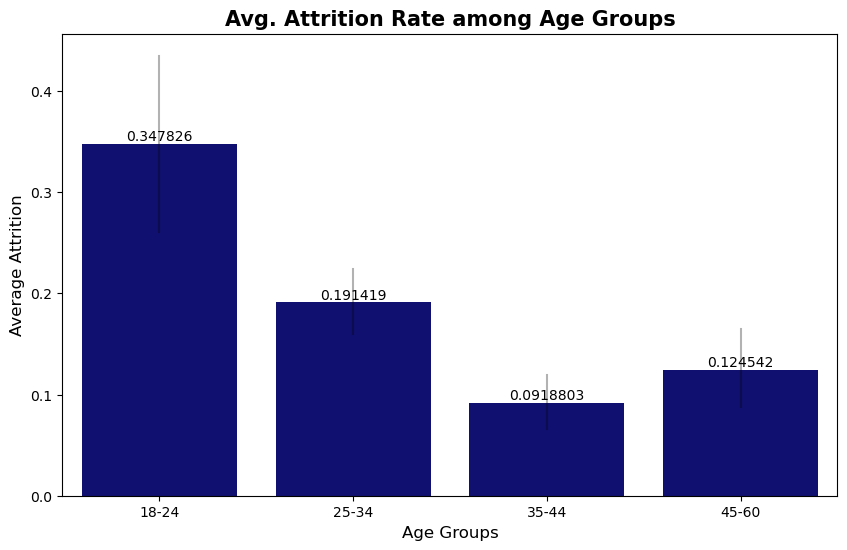

In [100]:
df.groupby('AgeGroup')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x='AgeGroup', y = "AttritionRate", data=df, color = 'navy', err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate among Age Groups', fontsize = 15, fontweight='bold')
ax.set_xlabel('Age Groups', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

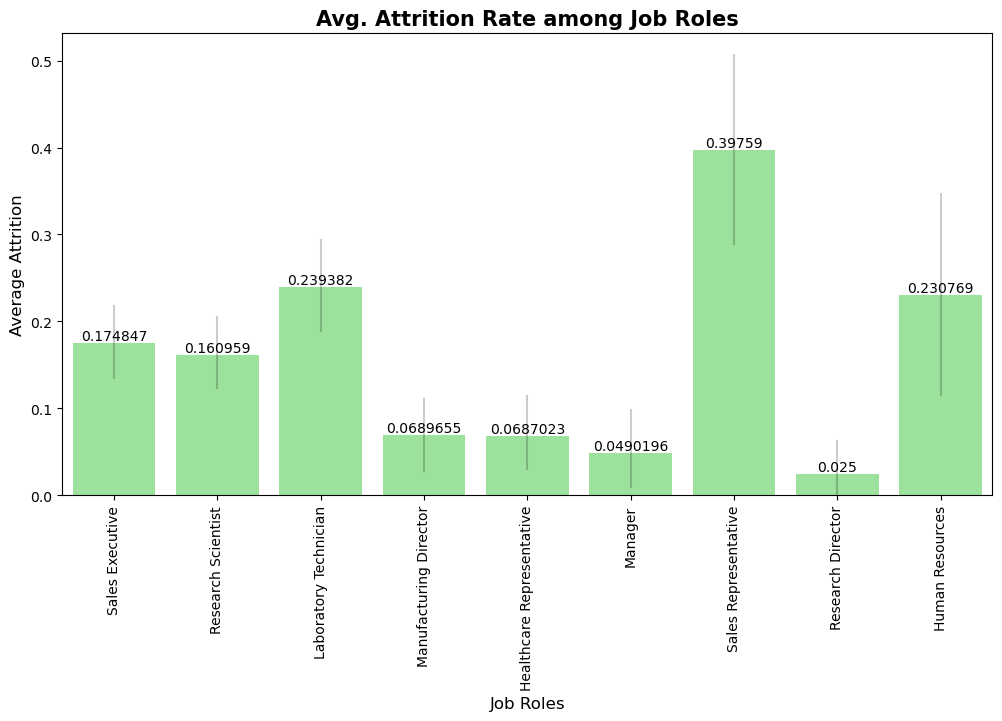

In [99]:
df.groupby('JobRole')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(12,6))
ax = sns.barplot(x='JobRole', y = "AttritionRate", data=df, color = 'lightgreen', err_kws={'color': 'black', 'alpha': 0.2, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate among Job Roles', fontsize = 15, fontweight='bold')
ax.set_xlabel('Job Roles', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()

In [36]:
#Converting Monthly Income into categories for better data visualisation

df['IncomeGroup'] = pd.cut(df["MonthlyIncome"], bins = [1000,5000,10000,15000,20000], labels = ['1000-5000','5001-10000','10001-15000','15001-20000'])


C:\Users\User\AppData\Local\Temp\ipykernel_8896\2009183252.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('IncomeGroup')['AttritionRate'].mean()


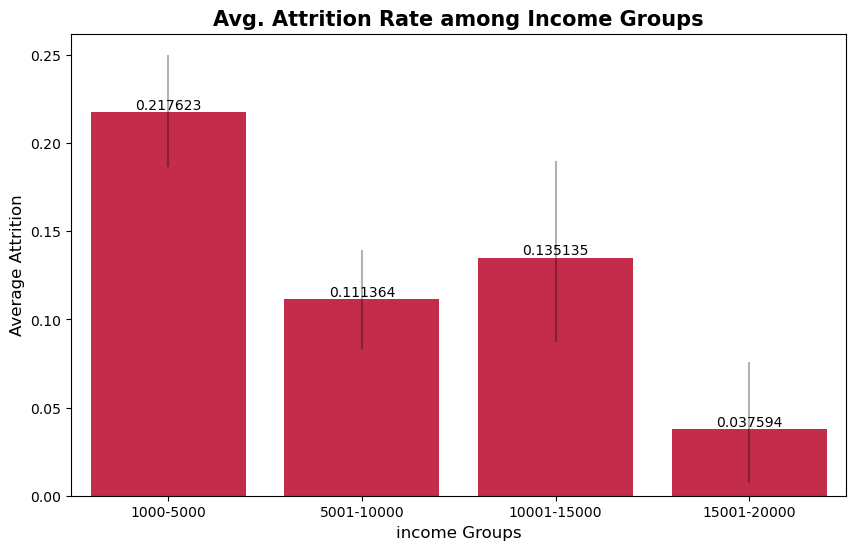

In [101]:
df.groupby('IncomeGroup')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(10,6))
ax = sns.barplot(x='IncomeGroup', y = "AttritionRate", data=df, color = 'crimson', err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate among Income Groups', fontsize = 15, fontweight='bold')
ax.set_xlabel('income Groups', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

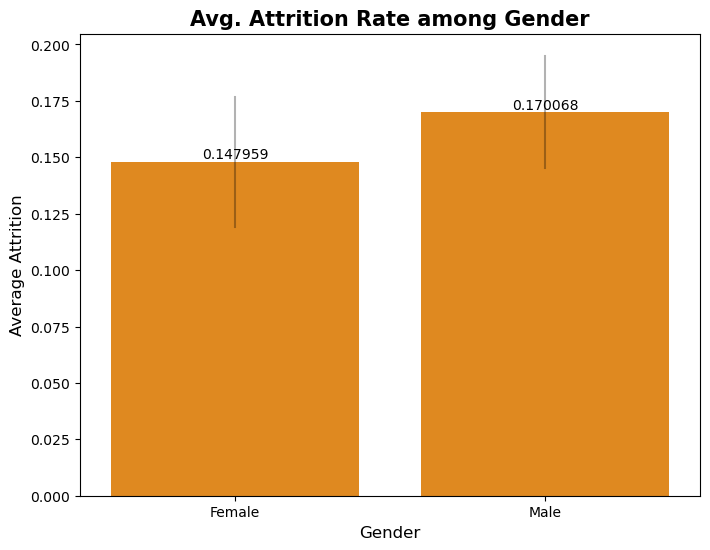

In [102]:
df.groupby('Gender')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.barplot(x='Gender', y = "AttritionRate", data=df, color = 'darkorange',err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate among Gender', fontsize = 15, fontweight='bold')
ax.set_xlabel('Gender', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

In [53]:
#Converting Years in Current Role into Categories (0-18)
df['Current Role Experience'] = pd.cut(df['YearsInCurrentRole'], bins = [0,5,10,15,20], labels = ['0-5','6-10','11-15','15-20'])

C:\Users\User\AppData\Local\Temp\ipykernel_8896\2557843879.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Current Role Experience')['AttritionRate'].mean()


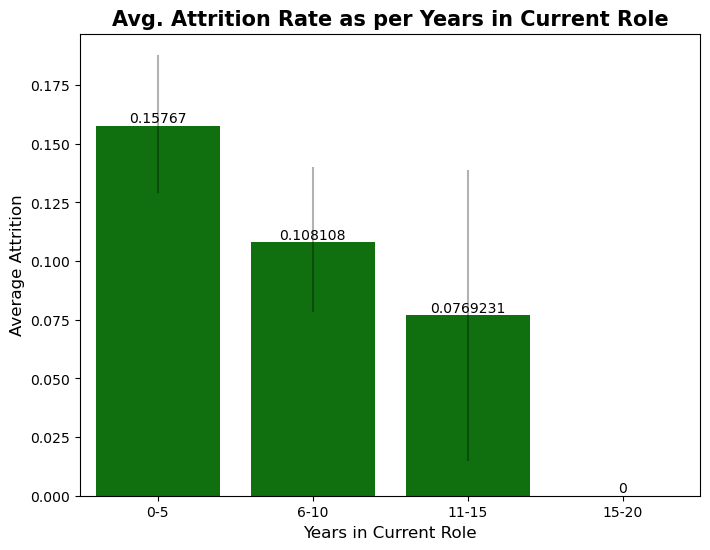

In [103]:
df.groupby('Current Role Experience')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.barplot(x='Current Role Experience', y = "AttritionRate", data=df, color = 'green',err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate as per Years in Current Role', fontsize = 15, fontweight='bold')
ax.set_xlabel('Years in Current Role', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
# COnverting Salary Hike into GRous
df['Salary hike %'] = pd.cut(df['PercentSalaryHike'], bins=[11, 15, 20, 25], labels=['11-15', '16-20', '21-25'])

C:\Users\User\AppData\Local\Temp\ipykernel_8896\4177900348.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Salary hike %')['AttritionRate'].mean()


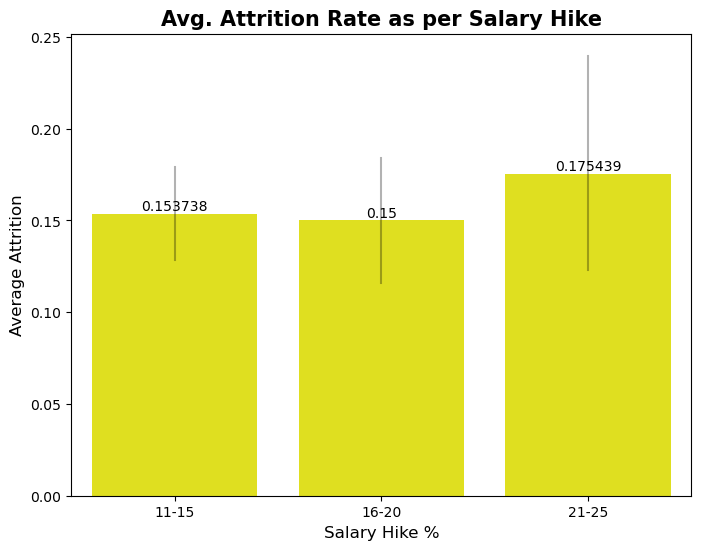

In [104]:
df.groupby('Salary hike %')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.barplot(x='Salary hike %', y = "AttritionRate", data=df, color = 'yellow',err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate as per Salary Hike', fontsize = 15, fontweight='bold')
ax.set_xlabel('Salary Hike %', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

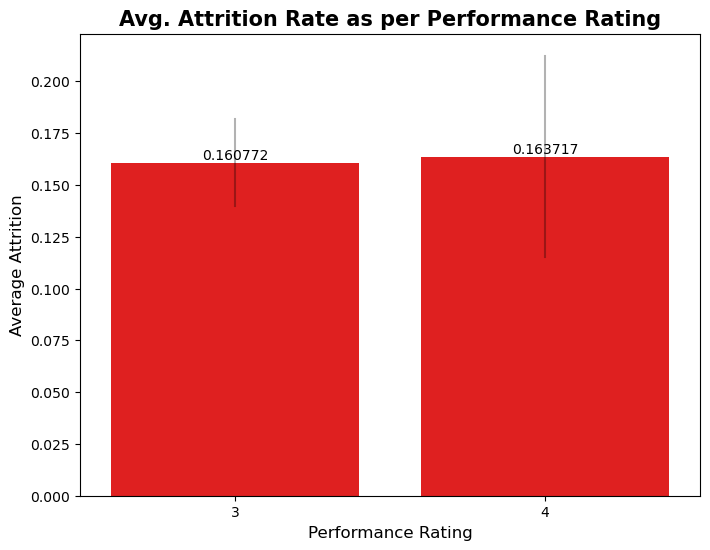

In [105]:

df.groupby('PerformanceRating')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.barplot(x='PerformanceRating', y = "AttritionRate", data=df, color = 'red',err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Avg. Attrition Rate as per Performance Rating', fontsize = 15, fontweight='bold')
ax.set_xlabel('Performance Rating', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

In [75]:
df['Office Distance kms'] = pd.cut(df['DistanceFromHome'], bins=[0,5,10,15,20,25,30], labels=['0-5','6-10','11-15','16-20','21-25','26-30'])           

C:\Users\User\AppData\Local\Temp\ipykernel_8896\2751340325.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Office Distance kms')['AttritionRate'].mean()


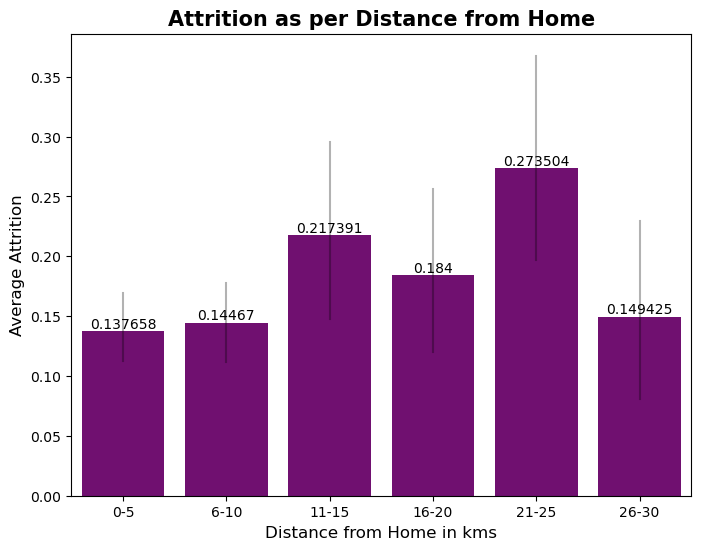

In [78]:

df.groupby('Office Distance kms')['AttritionRate'].mean()
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.barplot(x='Office Distance kms', y = "AttritionRate", data=df, color = 'purple',err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Attrition as per Distance from Home', fontsize = 15, fontweight='bold')
ax.set_xlabel('Distance from Home in kms', fontsize = 12)
ax.set_ylabel('Average Attrition', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()

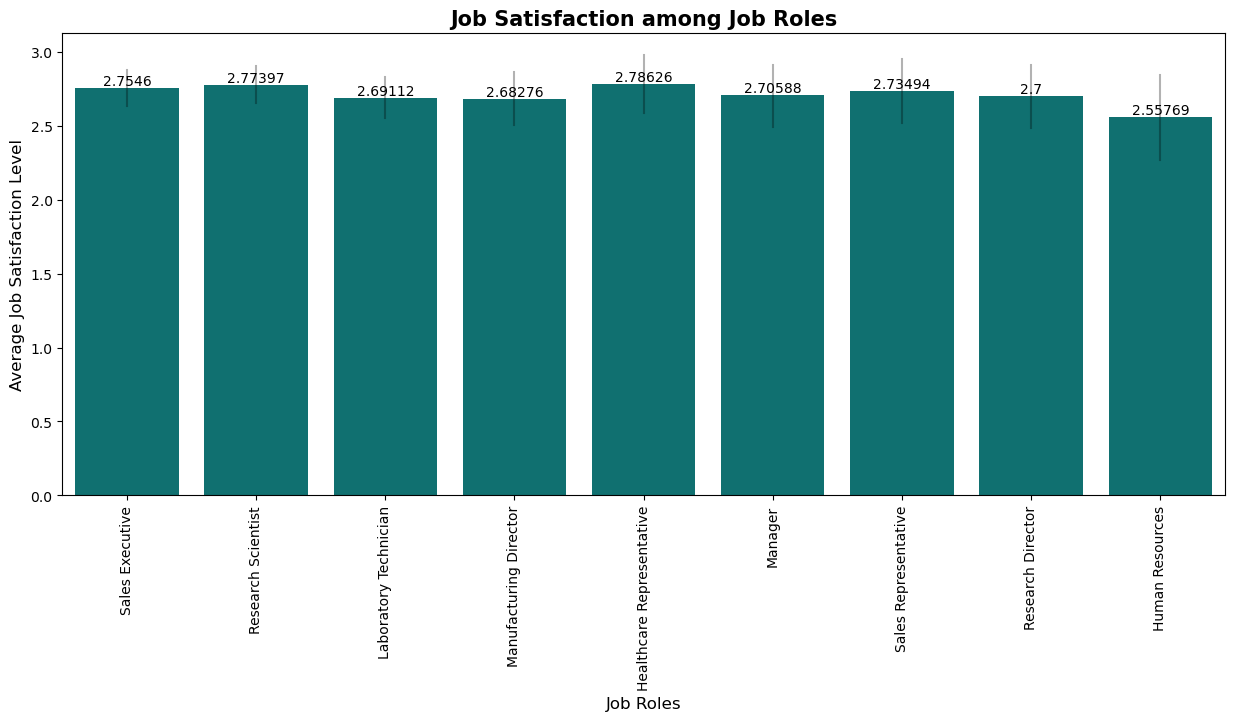

In [93]:

df.groupby('JobRole')['JobSatisfaction'].mean()
fig, ax = plt.subplots(figsize=(15,6))
ax = sns.barplot(x='JobRole', y = "JobSatisfaction", data=df, color = 'teal',err_kws={'color': 'black', 'alpha': 0.3, 'linewidth': 1.5})
ax.set_title('Job Satisfaction among Job Roles', fontsize = 15, fontweight='bold')
ax.set_xlabel('Job Roles', fontsize = 12)
ax.set_ylabel('Average Job Satisfaction Level', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()